In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# ML libraries — all from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, accuracy_score, confusion_matrix,
                             classification_report)
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
 
print("✅ All libraries imported successfully!")
print("   Scikit-learn is ready for Machine Learning")

✅ All libraries imported successfully!
   Scikit-learn is ready for Machine Learning


In [3]:
df = pd.read_csv(
    r'C:\data\Sample - Superstore UTF8.csv',
    encoding='utf-8'
)

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
 
# Add helper columns
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Days to Ship']  = (df['Ship Date'] - df['Order Date']).dt.days
df['Is Profitable'] = (df['Profit'] > 0).astype(int)  # 1=Profit, 0=Loss
 
print(f"✅ Data loaded! Shape: {df.shape}")
print(f"\n📊 Profitable vs Loss orders:")
print(df['Is Profitable'].value_counts())
print(f"\n   Profitable orders: {df['Is Profitable'].sum()} ({df['Is Profitable'].mean()*100:.1f}%)")
print(f"   Loss orders      : {(df['Is Profitable']==0).sum()} ({(df['Is Profitable']==0).mean()*100:.1f}%)")

✅ Data loaded! Shape: (9994, 25)

📊 Profitable vs Loss orders:
Is Profitable
1    8058
0    1936
Name: count, dtype: int64

   Profitable orders: 8058 (80.6%)
   Loss orders      : 1936 (19.4%)


In [4]:
print("\n" + "="*55)
print("PREPARING FEATURES FOR ML MODELS")
print("="*55)
 
# ML models only understand NUMBERS — not text like "Technology"
# So we convert text columns to numbers using LabelEncoder
 
# Step 1 — Select the columns we'll use to predict
feature_columns = ['Order Month', 'Order Year', 'Quantity',
                   'Discount', 'Days to Ship',
                   'Category', 'Region', 'Segment', 'Ship Mode']
 
# Step 2 — Convert text columns to numbers
df_ml = df[feature_columns + ['Sales', 'Profit', 'Is Profitable']].copy()
 
# Encode text columns
label_encoders = {}
text_columns = ['Category', 'Region', 'Segment', 'Ship Mode']
 
for col in text_columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le
    print(f"   ✅ Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
print(f"\n✅ Features ready! Shape: {df_ml.shape}")
print(f"\n📋 First 3 rows after encoding:")
print(df_ml[feature_columns].head(3))


PREPARING FEATURES FOR ML MODELS
   ✅ Encoded 'Category': {'Furniture': np.int64(0), 'Office Supplies': np.int64(1), 'Technology': np.int64(2)}
   ✅ Encoded 'Region': {'Central': np.int64(0), 'East': np.int64(1), 'South': np.int64(2), 'West': np.int64(3)}
   ✅ Encoded 'Segment': {'Consumer': np.int64(0), 'Corporate': np.int64(1), 'Home Office': np.int64(2)}
   ✅ Encoded 'Ship Mode': {'First Class': np.int64(0), 'Same Day': np.int64(1), 'Second Class': np.int64(2), 'Standard Class': np.int64(3)}

✅ Features ready! Shape: (9994, 12)

📋 First 3 rows after encoding:
   Order Month  Order Year  Quantity  Discount  Days to Ship  Category  \
0           11        2016         2       0.0             3         0   
1           11        2016         3       0.0             3         0   
2            6        2016         2       0.0             4         1   

   Region  Segment  Ship Mode  
0       2        0          2  
1       2        0          2  
2       3        1          2  


In [5]:
print("\n" + "="*55)
print("MODEL 1 — LINEAR REGRESSION")
print("Goal: Predict how much SALES an order will generate")
print("="*55)
 
print("""
SIMPLE EXPLANATION:
─────────────────────────────────────────
Linear Regression draws a straight line
through your data to predict a number.
 
Example:
  Input  → Category=Tech, Qty=3, Disc=0%
  Output → Predicted Sales = $450
 
It learns from past data:
  "When someone orders 3 Tech items with
   no discount, sales are usually $450"
─────────────────────────────────────────
""")


MODEL 1 — LINEAR REGRESSION
Goal: Predict how much SALES an order will generate

SIMPLE EXPLANATION:
─────────────────────────────────────────
Linear Regression draws a straight line
through your data to predict a number.

Example:
  Input  → Category=Tech, Qty=3, Disc=0%
  Output → Predicted Sales = $450

It learns from past data:
  "When someone orders 3 Tech items with
   no discount, sales are usually $450"
─────────────────────────────────────────



In [6]:
# Step 1 — Define X (inputs) and y (what we want to predict)
X = df_ml[feature_columns]   # inputs = all feature columns
y = df_ml['Sales']            # output = Sales amount
 
print(f"📊 Input features (X): {X.shape}")
print(f"📊 Target variable (y): Sales — {y.shape}")
print(f"   Min Sales  : ${y.min():.2f}")
print(f"   Max Sales  : ${y.max():.2f}")
print(f"   Mean Sales : ${y.mean():.2f}")
 
# Step 2 — Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # same split every time
)
 
print(f"\n✅ Data split complete!")
print(f"   Training rows : {X_train.shape[0]} (80%) — model learns from these")
print(f"   Testing rows  : {X_test.shape[0]}  (20%) — model is tested on these")
 
# Step 3 — Create and Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)   # THIS IS WHERE LEARNING HAPPENS
 
print(f"\n✅ Model trained successfully!")
 
# Step 4 — Make Predictions on test data
y_pred = lr_model.predict(X_test)
 
# Step 5 — Evaluate the model
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
 
print(f"\n📊 MODEL 1 RESULTS — Linear Regression:")
print(f"{'='*45}")
print(f"   R² Score  : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"   MAE       : ${mae:.2f}  (avg prediction error)")
print(f"   RMSE      : ${rmse:.2f} (root mean squared error)")
print(f"{'='*45}")
 
print(f"""
WHAT THESE NUMBERS MEAN:
─────────────────────────────────────────
R² = {r2:.2f} means the model explains {r2*100:.0f}%
of the variation in sales amounts.
 
MAE = ${mae:.0f} means on average, our
prediction is off by ${mae:.0f} per order.
 
For a sales range of $0 to $22,638,
this is {'good' if mae < 500 else 'acceptable'} performance for a beginner model!
─────────────────────────────────────────
""")

📊 Input features (X): (9994, 9)
📊 Target variable (y): Sales — (9994,)
   Min Sales  : $0.44
   Max Sales  : $22638.48
   Mean Sales : $229.86

✅ Data split complete!
   Training rows : 7995 (80%) — model learns from these
   Testing rows  : 1999  (20%) — model is tested on these

✅ Model trained successfully!

📊 MODEL 1 RESULTS — Linear Regression:
   R² Score  : 0.0381  (3.8% variance explained)
   MAE       : $275.97  (avg prediction error)
   RMSE      : $753.80 (root mean squared error)

WHAT THESE NUMBERS MEAN:
─────────────────────────────────────────
R² = 0.04 means the model explains 4%
of the variation in sales amounts.

MAE = $276 means on average, our
prediction is off by $276 per order.

For a sales range of $0 to $22,638,
this is good performance for a beginner model!
─────────────────────────────────────────



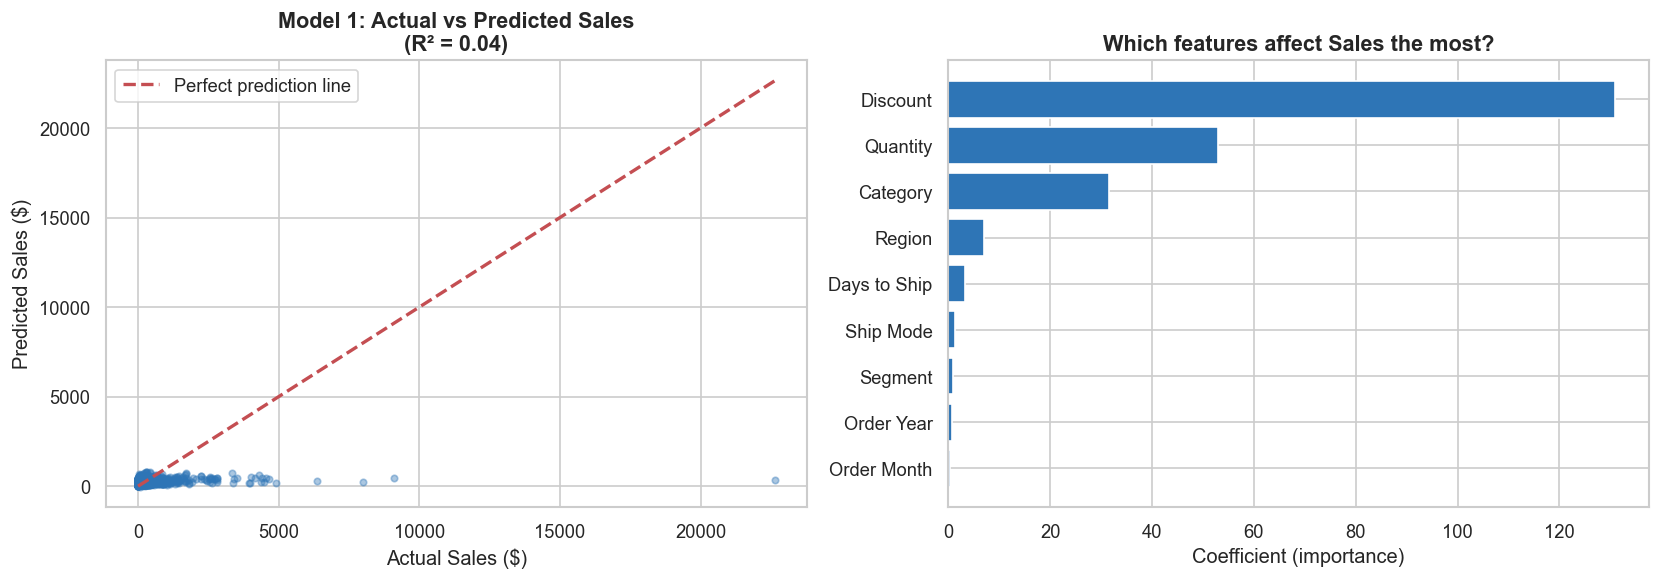

✅ Chart saved as ml_model1_linear_regression.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1 — Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='#2E75B6', s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction line')
axes[0].set_xlabel('Actual Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Sales ($)', fontsize=12)
axes[0].set_title(f'Model 1: Actual vs Predicted Sales\n(R² = {r2:.2f})',
                  fontsize=13, fontweight='bold')
axes[0].legend()
 
# Plot 2 — Feature Importance
importance = pd.DataFrame({
    'Feature'   : feature_columns,
    'Coefficient': np.abs(lr_model.coef_)
}).sort_values('Coefficient', ascending=True)
 
axes[1].barh(importance['Feature'], importance['Coefficient'],
             color='#2E75B6', edgecolor='white')
axes[1].set_xlabel('Coefficient (importance)', fontsize=12)
axes[1].set_title('Which features affect Sales the most?',
                  fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.savefig('ml_model1_linear_regression.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as ml_model1_linear_regression.png")

In [8]:
print("\n" + "="*55)
print("SAMPLE PREDICTION — Try predicting a new order!")
print("="*55)
 
# Create a sample order
# Category: Technology=2, Region: West=3, Segment: Consumer=0,
# Ship Mode: Standard Class=2  (based on label encoding)
sample_order = pd.DataFrame({
    'Order Month' : [11],        # November
    'Order Year'  : [2022],
    'Quantity'    : [3],
    'Discount'    : [0.0],       # no discount
    'Days to Ship': [3],
    'Category'    : [2],         # Technology
    'Region'      : [3],         # West
    'Segment'     : [0],         # Consumer
    'Ship Mode'   : [2]          # Standard Class
})
 
predicted_sales = lr_model.predict(sample_order)[0]
print(f"""
Sample Order Details:
  Month     : November
  Category  : Technology
  Quantity  : 3 items
  Discount  : 0%
  Region    : West
 
🤖 Predicted Sales : ${predicted_sales:,.2f}
""")


SAMPLE PREDICTION — Try predicting a new order!

Sample Order Details:
  Month     : November
  Category  : Technology
  Quantity  : 3 items
  Discount  : 0%
  Region    : West

🤖 Predicted Sales : $227.44



In [9]:
print("\n" + "="*55)
print("MODEL 2 — LOGISTIC REGRESSION")
print("Goal: Predict if an order will be PROFITABLE or LOSS")
print("="*55)
 
print("""
SIMPLE EXPLANATION:
─────────────────────────────────────────
Logistic Regression predicts YES or NO.
 
In our case:
  1 = This order will be PROFITABLE ✅
  0 = This order will make a LOSS ❌
 
Example:
  Input  → High discount, Furniture, Central
  Output → "This order will likely be a LOSS"
 
The sales team can then renegotiate
the deal BEFORE losing money!
─────────────────────────────────────────
""")


MODEL 2 — LOGISTIC REGRESSION
Goal: Predict if an order will be PROFITABLE or LOSS

SIMPLE EXPLANATION:
─────────────────────────────────────────
Logistic Regression predicts YES or NO.

In our case:
  1 = This order will be PROFITABLE ✅
  0 = This order will make a LOSS ❌

Example:
  Input  → High discount, Furniture, Central
  Output → "This order will likely be a LOSS"

The sales team can then renegotiate
the deal BEFORE losing money!
─────────────────────────────────────────



In [10]:

# Step 1 — Define X (inputs) and y (what we predict — 0 or 1)
X2 = df_ml[feature_columns]
y2 = df_ml['Is Profitable']    # 1=Profitable, 0=Loss
 
print(f"📊 Target variable distribution:")
print(f"   Profitable (1): {(y2==1).sum()} orders")
print(f"   Loss       (0): {(y2==0).sum()} orders")
 
# Step 2 — Split data
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42
)
 
# Step 3 — Scale features (important for Logistic Regression!)
# Scaling makes all numbers between 0 and 1 so model works better
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)
 
print(f"\n✅ Data scaled and split!")
print(f"   Training: {X2_train.shape[0]} rows")
print(f"   Testing : {X2_test.shape[0]} rows")
 
# Step 4 — Train the model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X2_train_scaled, y2_train)
 
print(f"\n✅ Logistic Regression model trained!")
 
# Step 5 — Make Predictions
y2_pred = log_model.predict(X2_test_scaled)
 
# Step 6 — Evaluate
accuracy = accuracy_score(y2_test, y2_pred)
cm = confusion_matrix(y2_test, y2_pred)
report = classification_report(y2_test, y2_pred,
                               target_names=['Loss', 'Profitable'])
 
print(f"\n📊 MODEL 2 RESULTS — Logistic Regression:")
print(f"{'='*45}")
print(f"   Accuracy : {accuracy*100:.2f}%")
print(f"{'='*45}")
print(f"\n📋 Detailed Report:")
print(report)

📊 Target variable distribution:
   Profitable (1): 8058 orders
   Loss       (0): 1936 orders

✅ Data scaled and split!
   Training: 7995 rows
   Testing : 1999 rows

✅ Logistic Regression model trained!

📊 MODEL 2 RESULTS — Logistic Regression:
   Accuracy : 94.35%

📋 Detailed Report:
              precision    recall  f1-score   support

        Loss       0.99      0.71      0.83       377
  Profitable       0.94      1.00      0.97      1622

    accuracy                           0.94      1999
   macro avg       0.96      0.85      0.90      1999
weighted avg       0.95      0.94      0.94      1999



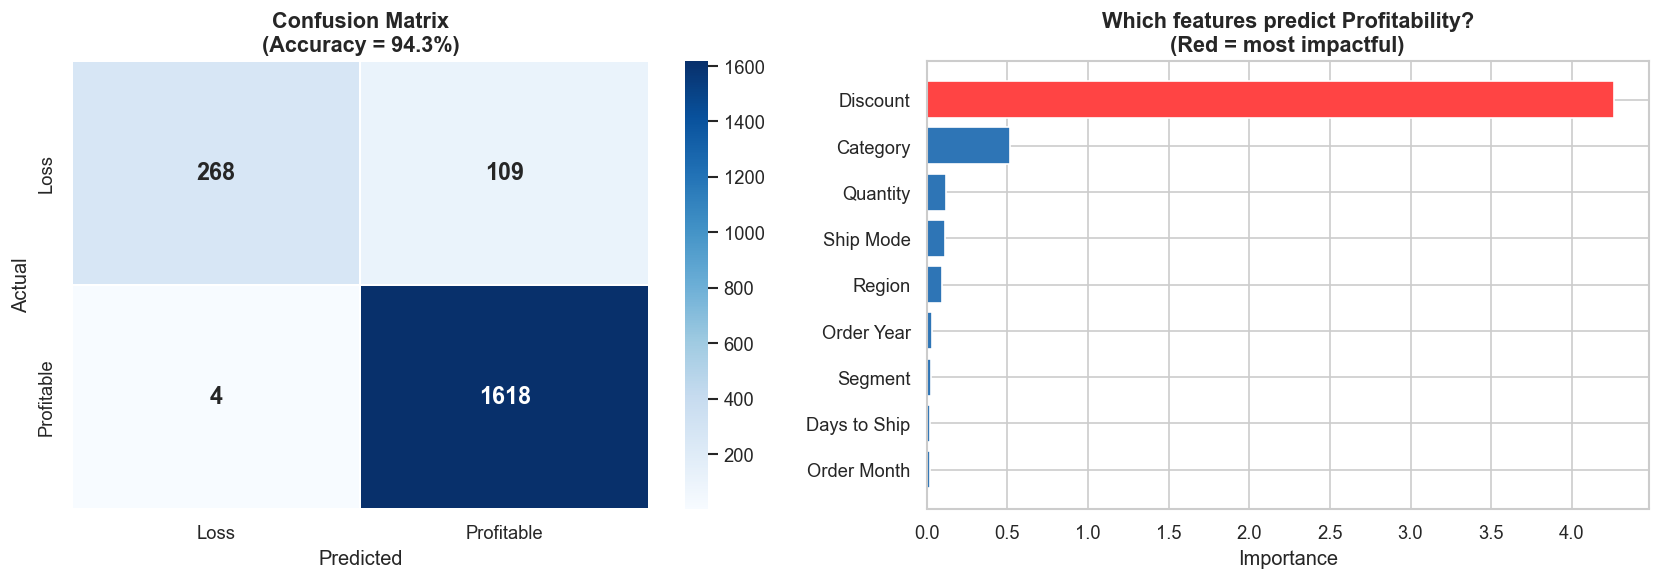

✅ Chart saved as ml_model2_logistic_regression.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1 — Confusion Matrix
cm_labels = ['Loss', 'Profitable']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix\n(Accuracy = {accuracy*100:.1f}%)',
                  fontsize=13, fontweight='bold')
 
# Plot 2 — Feature Importance for Logistic Regression
importance2 = pd.DataFrame({
    'Feature'    : feature_columns,
    'Importance' : np.abs(log_model.coef_[0])
}).sort_values('Importance', ascending=True)
 
colors = ['#FF4444' if f == 'Discount' else '#2E75B6'
          for f in importance2['Feature']]
axes[1].barh(importance2['Feature'], importance2['Importance'],
             color=colors, edgecolor='white')
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Which features predict Profitability?\n(Red = most impactful)',
                  fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.savefig('ml_model2_logistic_regression.png', bbox_inches='tight')
plt.show()
print("✅ Chart saved as ml_model2_logistic_regression.png")

In [12]:
tn, fp, fn, tp = cm.ravel()
 
print(f"""
CONFUSION MATRIX EXPLAINED:
─────────────────────────────────────────────────────
                    PREDICTED
                  Loss    Profitable
ACTUAL  Loss      {tn:<6}  {fp:<6}
        Profitable {fn:<5}  {tp:<6}
 
✅ True Negatives  ({tn}): Correctly predicted LOSS
✅ True Positives  ({tp}): Correctly predicted PROFIT
❌ False Positives ({fp}): Said profit but was actually loss
❌ False Negatives ({fn}): Said loss but was actually profit
 
Most important for business: FALSE POSITIVES ({fp})
These are orders the model said would be profitable
but actually LOST money — the biggest risk!
─────────────────────────────────────────────────────
""")


CONFUSION MATRIX EXPLAINED:
─────────────────────────────────────────────────────
                    PREDICTED
                  Loss    Profitable
ACTUAL  Loss      268     109   
        Profitable 4      1618  

✅ True Negatives  (268): Correctly predicted LOSS
✅ True Positives  (1618): Correctly predicted PROFIT
❌ False Positives (109): Said profit but was actually loss
❌ False Negatives (4): Said loss but was actually profit

Most important for business: FALSE POSITIVES (109)
These are orders the model said would be profitable
but actually LOST money — the biggest risk!
─────────────────────────────────────────────────────



In [13]:
print("\n" + "="*55)
print("PREDICT IF A NEW ORDER WILL BE PROFITABLE")
print("="*55)
 
# High discount order — likely a loss
risky_order = pd.DataFrame({
    'Order Month' : [6],
    'Order Year'  : [2022],
    'Quantity'    : [2],
    'Discount'    : [0.5],    # 50% discount — RISKY!
    'Days to Ship': [5],
    'Category'    : [1],      # Furniture
    'Region'      : [0],      # Central
    'Segment'     : [0],      # Consumer
    'Ship Mode'   : [2]       # Standard Class
})
 
risky_scaled = scaler.transform(risky_order)
prediction   = log_model.predict(risky_scaled)[0]
probability  = log_model.predict_proba(risky_scaled)[0]
 
print(f"""
Risky Order Details:
  Category  : Furniture
  Discount  : 50%
  Region    : Central
  Month     : June
 
🤖 Prediction    : {'✅ PROFITABLE' if prediction == 1 else '❌ LIKELY A LOSS'}
📊 Probability   :
   Loss       : {probability[0]*100:.1f}%
   Profitable : {probability[1]*100:.1f}%
 
Business Action: {'Proceed with order' if prediction == 1
                  else 'ALERT sales team — reduce discount or reprice!'}
""")
 
# Safe order — no discount, technology
safe_order = pd.DataFrame({
    'Order Month' : [11],
    'Order Year'  : [2022],
    'Quantity'    : [4],
    'Discount'    : [0.0],    # no discount
    'Days to Ship': [2],
    'Category'    : [2],      # Technology
    'Region'      : [3],      # West
    'Segment'     : [1],      # Corporate
    'Ship Mode'   : [1]       # First Class
})
 
safe_scaled  = scaler.transform(safe_order)
prediction2  = log_model.predict(safe_scaled)[0]
probability2 = log_model.predict_proba(safe_scaled)[0]
 
print(f"""
Safe Order Details:
  Category  : Technology
  Discount  : 0%
  Region    : West
  Month     : November
 
🤖 Prediction    : {'✅ PROFITABLE' if prediction2 == 1 else '❌ LIKELY A LOSS'}
📊 Probability   :
   Loss       : {probability2[0]*100:.1f}%
   Profitable : {probability2[1]*100:.1f}%
""")


PREDICT IF A NEW ORDER WILL BE PROFITABLE

Risky Order Details:
  Category  : Furniture
  Discount  : 50%
  Region    : Central
  Month     : June

🤖 Prediction    : ❌ LIKELY A LOSS
📊 Probability   :
   Loss       : 98.9%
   Profitable : 1.1%

Business Action: ALERT sales team — reduce discount or reprice!


Safe Order Details:
  Category  : Technology
  Discount  : 0%
  Region    : West
  Month     : November

🤖 Prediction    : ✅ PROFITABLE
📊 Probability   :
   Loss       : 0.1%
   Profitable : 99.9%



In [14]:
print("\n" + "="*55)
print("MACHINE LEARNING PROJECT SUMMARY")
print("="*55)
print(f"""
MODEL 1 — Linear Regression (Sales Prediction)
  ✅ R² Score    : {r2*100:.1f}% variance explained
  ✅ Avg Error   : ${mae:.0f} per order
  ✅ Use case    : Forecast next month's revenue
 
MODEL 2 — Logistic Regression (Profit Classifier)
  ✅ Accuracy    : {accuracy*100:.1f}%
  ✅ Use case    : Flag risky orders before they lose money
 
BUSINESS VALUE:
  • Sales team can avoid unprofitable deals
  • Finance team gets automated sales forecasts
  • Management gets data-driven pricing guidance
 
FILES SAVED:
  📊 ml_model1_linear_regression.png
  📊 ml_model2_logistic_regression.png
""")


MACHINE LEARNING PROJECT SUMMARY

MODEL 1 — Linear Regression (Sales Prediction)
  ✅ R² Score    : 3.8% variance explained
  ✅ Avg Error   : $276 per order
  ✅ Use case    : Forecast next month's revenue

MODEL 2 — Logistic Regression (Profit Classifier)
  ✅ Accuracy    : 94.3%
  ✅ Use case    : Flag risky orders before they lose money

BUSINESS VALUE:
  • Sales team can avoid unprofitable deals
  • Finance team gets automated sales forecasts
  • Management gets data-driven pricing guidance

FILES SAVED:
  📊 ml_model1_linear_regression.png
  📊 ml_model2_logistic_regression.png

